In [1]:
import pandas as pd

final_df = pd.read_csv(
    "../data/processed/final_restaurant_data.csv"
)

In [2]:
reviews = pd.read_json(
    "../data/raw/yelp_academic_dataset_review.json",
    lines=True,
    nrows=50000
)

In [3]:
reviews.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [5]:
reviews.columns

Index(['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
       'cool', 'text', 'date'],
      dtype='object')

In [6]:
restaurant_reviews = reviews.merge(
    final_df,
    on='business_id',
    how='inner'
)

In [7]:
restaurant_reviews.shape

(12648, 19)

In [8]:
restaurant_reviews.head()

,review_id,user_id,business_id,stars_x,useful,funny,cool,text,date,name,city,state,stars_y,review_count,main_category,delivery,outdoor_seating,reservations,wifi
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,North Wales,PA,3.0,169,Breakfast & Brunch,True,True,False,'free'
1,VJxlBnJmCDIy8DFG0kjSow,Iaee7y6zdSB3B-kRCo4z1w,XQfwVwDr-v0ZS3_CbbE5Xw,2,0,0,0,This is the second time we tried turning point...,2017-05-13 17:06:55,Turning Point of North Wales,North Wales,PA,3.0,169,Breakfast & Brunch,True,True,False,'free'
2,S6pQZQocMB1WHMjTRbt77A,ejFxLGqQcWNLdNByJlIhnQ,XQfwVwDr-v0ZS3_CbbE5Xw,4,2,0,1,The place is cute and the staff was very frien...,2017-08-08 00:58:18,Turning Point of North Wales,North Wales,PA,3.0,169,Breakfast & Brunch,True,True,False,'free'
3,WqgTKVqWVHDHjnjEsBvUgg,f7xa0p_1V9lx53iIGN5Sug,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,We came on a Saturday morning after waiting a ...,2017-11-19 02:20:23,Turning Point of North Wales,North Wales,PA,3.0,169,Breakfast & Brunch,True,True,False,'free'
4,M0wzFFb7pefOPcxeRVbLag,dCooFVCk8M1nVaQqcfTL3Q,XQfwVwDr-v0ZS3_CbbE5Xw,2,0,0,0,"Mediocre at best. The decor is very nice, and ...",2017-09-09 17:49:47,Turning Point of North Wales,North Wales,PA,3.0,169,Breakfast & Brunch,True,True,False,'free'


In [10]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [13]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [14]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    filtered_words = [
        word
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [15]:
restaurant_reviews['cleaned_text'] = (
    restaurant_reviews['text']
    .astype(str)
    .apply(clean_text)
)

In [16]:
from textblob import TextBlob

def get_sentiment(text):

    analysis = TextBlob(text)

    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return 'Positive'

    elif polarity < 0:
        return 'Negative'

    else:
        return 'Neutral'

In [17]:
restaurant_reviews['sentiment'] = (
    restaurant_reviews['cleaned_text']
    .apply(get_sentiment)
)

In [18]:
restaurant_reviews['sentiment'].value_counts()

sentiment
Positive    11340
Negative     1231
Neutral        77
Name: count, dtype: int64

In [19]:
import plotly.express as px

sentiment_counts = (
    restaurant_reviews['sentiment']
    .value_counts()
    .reset_index()
)

sentiment_counts.columns = [
    'Sentiment',
    'Count'
]

fig = px.pie(
    sentiment_counts,
    names='Sentiment',
    values='Count',
    title='Review Sentiment Distribution'
)

fig.show()

In [22]:
restaurant_reviews_sample = restaurant_reviews.head(5000)

In [23]:
import plotly.express as px

sentiment_counts = (
    restaurant_reviews_sample['sentiment']
    .value_counts()
    .reset_index()
)

sentiment_counts.columns = [
    'Sentiment',
    'Count'
]

fig = px.pie(
    sentiment_counts,
    names='Sentiment',
    values='Count',
    title='Review Sentiment Distribution'
)

fig.show()

In [24]:
cuisine_sentiment = (
    restaurant_reviews_sample
    .groupby('main_category')['sentiment']
    .value_counts()
    .unstack()
    .fillna(0)
)

cuisine_sentiment.head()

sentiment,Negative,Neutral,Positive
main_category,,,
American (New),20.0,0.0,123.0
American (Traditional),10.0,1.0,199.0
Arts & Entertainment,1.0,0.0,8.0
Automotive,0.0,0.0,5.0
Bagels,1.0,0.0,29.0


In [25]:
positive_cuisines = (
    restaurant_reviews_sample[
        restaurant_reviews_sample['sentiment'] == 'Positive'
    ]
    .groupby('main_category')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

positive_cuisines

main_category
German                    477
Breakfast & Brunch        360
American (Traditional)    199
Donuts                    175
Cocktail Bars             159
Live/Raw Food             155
Pizza                     149
Sports Bars               131
Vietnamese                128
American (New)            123
dtype: int64

In [26]:
fig = px.bar(
    positive_cuisines,
    title='Top Cuisines with Positive Reviews'
)

fig.show()

In [27]:
from collections import Counter

positive_words = " ".join(
    restaurant_reviews_sample[
        restaurant_reviews_sample['sentiment'] == 'Positive'
    ]['cleaned_text']
)

word_list = positive_words.split()

common_positive_words = Counter(word_list).most_common(20)

common_positive_words

[('good', 2903),
 ('food', 2791),
 ('place', 2356),
 ('great', 2349),
 ('service', 1788),
 ('one', 1325),
 ('like', 1275),
 ('time', 1224),
 ('back', 1219),
 ('really', 1208),
 ('get', 1119),
 ('would', 1108),
 ('go', 1091),
 ('also', 1048),
 ('best', 1046),
 ('ordered', 1009),
 ('delicious', 1003),
 ('us', 956),
 ('restaurant', 898),
 ('menu', 883)]

In [28]:
negative_words = " ".join(
    restaurant_reviews_sample[
        restaurant_reviews_sample['sentiment'] == 'Negative'
    ]['cleaned_text']
)

negative_word_list = negative_words.split()

common_negative_words = Counter(
    negative_word_list
).most_common(20)

common_negative_words

[('food', 310),
 ('service', 180),
 ('place', 178),
 ('like', 133),
 ('chicken', 127),
 ('back', 123),
 ('one', 122),
 ('time', 120),
 ('would', 114),
 ('us', 110),
 ('get', 104),
 ('go', 103),
 ('ordered', 101),
 ('order', 95),
 ('even', 92),
 ('didnt', 91),
 ('came', 86),
 ('never', 85),
 ('got', 80),
 ('good', 77)]

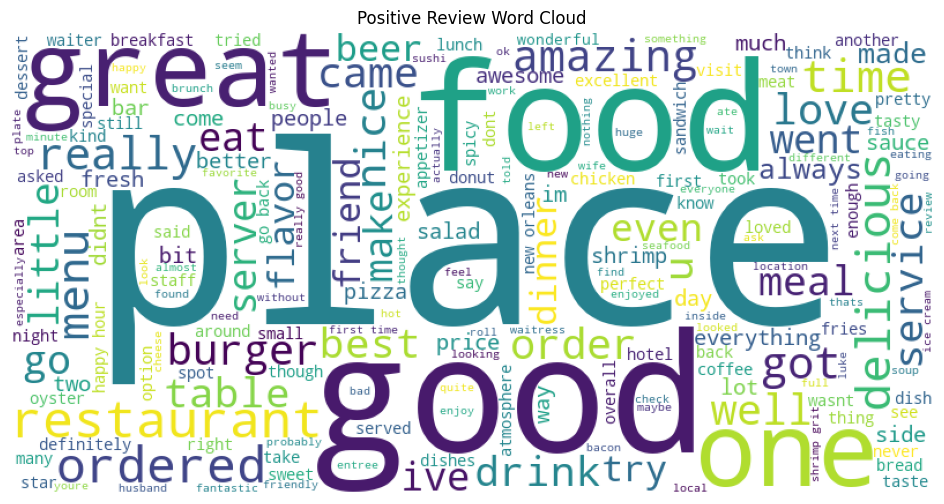

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Review Word Cloud")

plt.show()

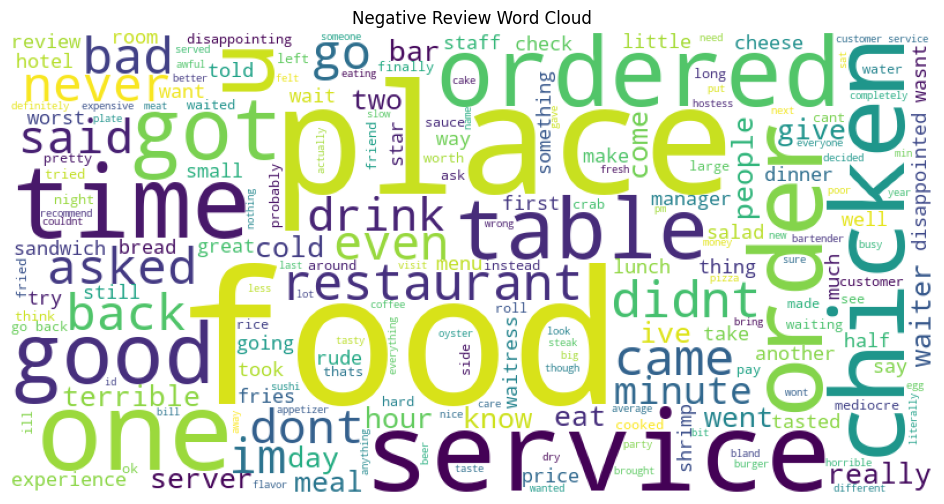

In [30]:
negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_words)

plt.figure(figsize=(12,6))

plt.imshow(negative_wordcloud)

plt.axis('off')

plt.title("Negative Review Word Cloud")

plt.show()

In [31]:
from collections import Counter

positive_words = " ".join(
    restaurant_reviews_sample[
        restaurant_reviews_sample['sentiment'] == 'Positive'
    ]['cleaned_text']
)

word_list = positive_words.split()

common_positive_words = Counter(
    word_list
).most_common(20)

common_positive_words

[('good', 2903),
 ('food', 2791),
 ('place', 2356),
 ('great', 2349),
 ('service', 1788),
 ('one', 1325),
 ('like', 1275),
 ('time', 1224),
 ('back', 1219),
 ('really', 1208),
 ('get', 1119),
 ('would', 1108),
 ('go', 1091),
 ('also', 1048),
 ('best', 1046),
 ('ordered', 1009),
 ('delicious', 1003),
 ('us', 956),
 ('restaurant', 898),
 ('menu', 883)]

In [32]:
negative_words = " ".join(
    restaurant_reviews_sample[
        restaurant_reviews_sample['sentiment'] == 'Negative'
    ]['cleaned_text']
)

negative_word_list = negative_words.split()

common_negative_words = Counter(
    negative_word_list
).most_common(20)

common_negative_words

[('food', 310),
 ('service', 180),
 ('place', 178),
 ('like', 133),
 ('chicken', 127),
 ('back', 123),
 ('one', 122),
 ('time', 120),
 ('would', 114),
 ('us', 110),
 ('get', 104),
 ('go', 103),
 ('ordered', 101),
 ('order', 95),
 ('even', 92),
 ('didnt', 91),
 ('came', 86),
 ('never', 85),
 ('got', 80),
 ('good', 77)]

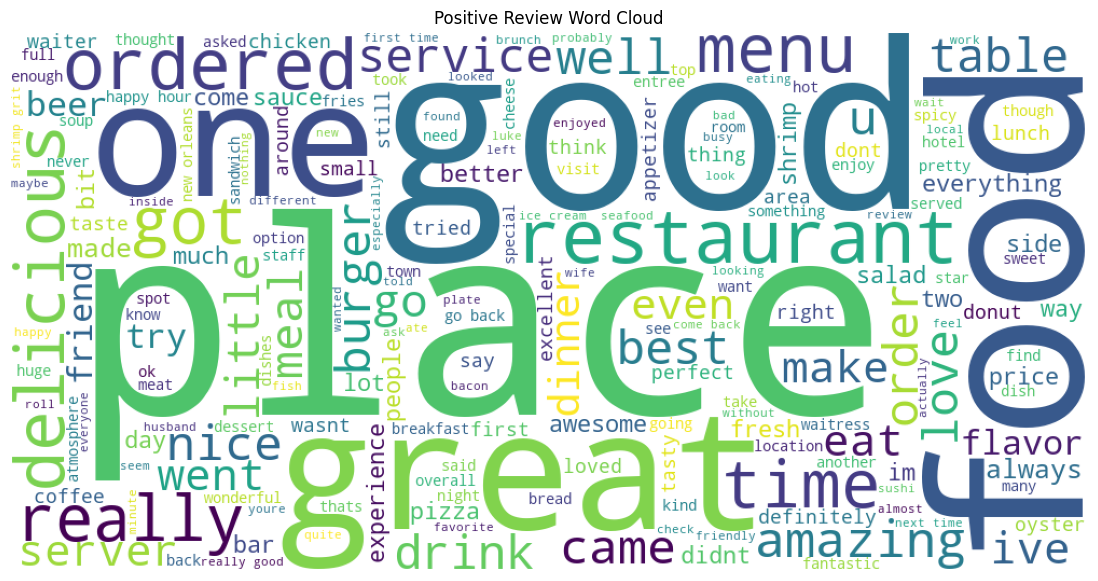

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_words)

plt.figure(figsize=(15,7))

plt.imshow(positive_wordcloud)

plt.axis('off')

plt.title("Positive Review Word Cloud")

plt.show()

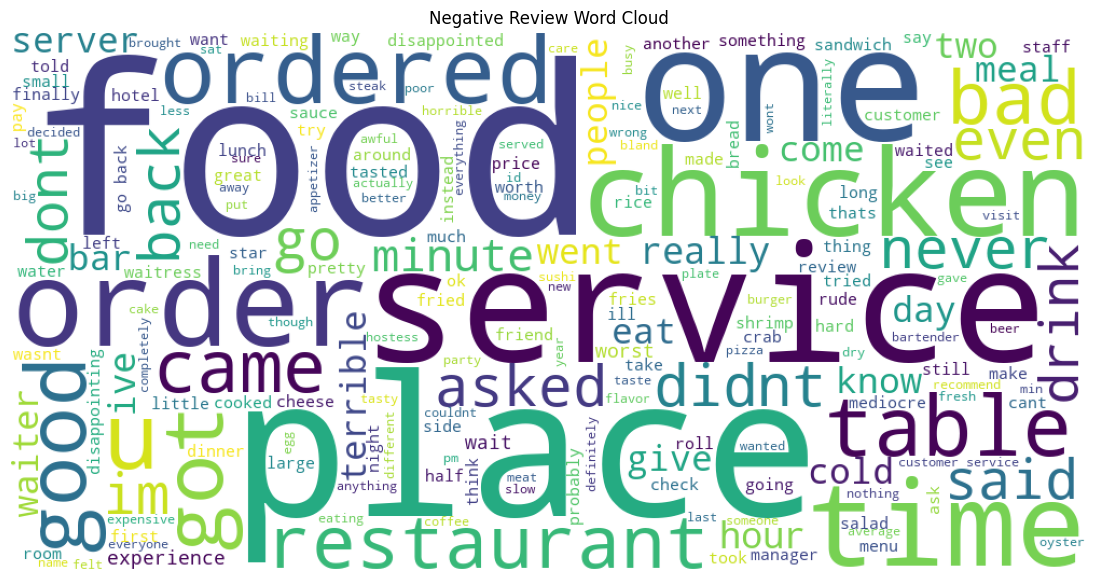

In [34]:
negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_words)

plt.figure(figsize=(15,7))

plt.imshow(negative_wordcloud)

plt.axis('off')

plt.title("Negative Review Word Cloud")

plt.show()

In [35]:
cuisine_sentiment = (
    restaurant_reviews_sample
    .groupby('main_category')['sentiment']
    .value_counts()
    .unstack()
    .fillna(0)
)

cuisine_sentiment.head()

sentiment,Negative,Neutral,Positive
main_category,,,
American (New),20.0,0.0,123.0
American (Traditional),10.0,1.0,199.0
Arts & Entertainment,1.0,0.0,8.0
Automotive,0.0,0.0,5.0
Bagels,1.0,0.0,29.0


In [36]:
positive_cuisine_counts = (
    restaurant_reviews_sample[
        restaurant_reviews_sample['sentiment'] == 'Positive'
    ]
    .groupby('main_category')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

positive_cuisine_counts

main_category
German                    477
Breakfast & Brunch        360
American (Traditional)    199
Donuts                    175
Cocktail Bars             159
Live/Raw Food             155
Pizza                     149
Sports Bars               131
Vietnamese                128
American (New)            123
dtype: int64

In [37]:
import plotly.express as px

fig = px.bar(
    positive_cuisine_counts,
    title='Top Cuisines with Positive Reviews'
)

fig.show()

In [38]:
restaurant_reviews_sample.to_csv(
    "../data/processed/restaurant_reviews_sentiment.csv",
    index=False
)